In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import datetime, date, time, timedelta
import pyperclip as pyp 

### <span style= "color: rgba(27,230,0, 0.88);"> **CARGAMOS Y LIMPIAMPS LOS DATOS** </span>
##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Realizamos graficos para ver la evolucion de cada base de datos** </span>
##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas** </span>

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28424\267537249.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_abejas,


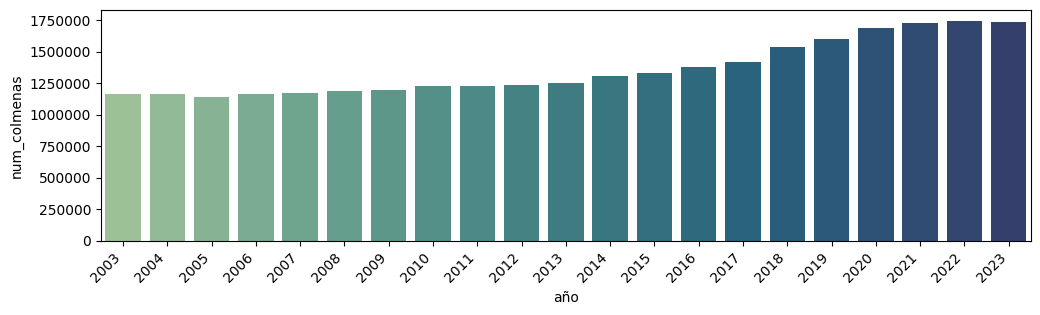

In [310]:
df_abejas = pd.read_csv(r"C:\Users\Usuario\Downloads\Faostat_bees_2000_2024.csv")
df_abejas.columns = df_abejas.columns.str.strip().str.lower().str.replace(" ", "_")
df_abejas
df_abejas = df_abejas[["área", "año", "valor"]]
df_abejas = df_abejas.rename(columns={"área":"pais",
                                      "valor":"num_colmenas"})
df_abejas = df_abejas[df_abejas["año"] != 2024]
df_abejas = df_abejas[df_abejas["año"] != 2000]
df_abejas = df_abejas[df_abejas["año"] != 2001]
df_abejas = df_abejas[df_abejas["año"] != 2002]


plt.figure(figsize=(12,3))
sns.barplot(data=df_abejas,
            x="año",
            y="num_colmenas",
            errorbar=None,
            palette="crest").ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45, ha="right")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Producción agricola** </span>

In [296]:
df_produccion_agri = pd.read_csv(r"C:\Users\Usuario\Downloads\Faostat_prodduction_2000_2024.csv")
df_produccion_agri.columns = df_produccion_agri.columns.str.strip().str.lower().str.replace(" ", "_")
df_produccion_agri = df_produccion_agri[["area","year","item","unit","element","value"]]
df_produccion_agri = df_produccion_agri.rename(columns={"area":"país",
                                                        "year":"año",
                                                        "value":"cantidad",
                                                        "item":"cultivo",
                                                        "unit":"unidad",
                                                        "element":"tipo"})

df_produccion_agri["cultivo"] = df_produccion_agri["cultivo"].replace({"Maize (corn)": "Maíz",
                                                                        "Soya beans": "Soja",
                                                                        "Wheat": "Trigo"})

df_produccion_agri["tipo"] = df_produccion_agri["tipo"].replace({"Area harvested": "area cosechada",
                                                                        "Yield": "rendimiento kg/h",
                                                                        "Production": "cosecha "})

df_produccion_agri = df_produccion_agri.pivot_table(
    index=["país", "año", "cultivo"],
    columns="tipo",
    values="cantidad",
    aggfunc="first"
).reset_index()

df_produccion_agri.columns.name = None
df_produccion_agri = df_produccion_agri[df_produccion_agri["año"] != 2024]
df_produccion_agri = df_produccion_agri[df_produccion_agri["año"] != 2000]
df_produccion_agri = df_produccion_agri[df_produccion_agri["año"] != 2001]
df_produccion_agri = df_produccion_agri[df_produccion_agri["año"] != 2002]
df_produccion_agri =df_produccion_agri.sort_values(["país", "año"])

df_produccion_agri

,país,año,cultivo,area cosechada,cosecha,rendimiento kg/h
9,France,2003,Maíz,1684639.0,12045463.6,7150.2
10,France,2003,Soja,80747.0,147367.6,1825.1
11,France,2003,Trigo,4876697.0,30479361.5,6250.0
12,France,2004,Maíz,1821419.0,16375868.0,8990.7
13,France,2004,Soja,58594.0,147095.0,2510.4
...,...,...,...,...,...,...
730,United States of America,2022,Soja,34873760.0,116220720.0,3332.6
731,United States of America,2022,Trigo,14360420.0,44897830.0,3126.5
732,United States of America,2023,Maíz,35010950.0,389694460.0,11130.6
733,United States of America,2023,Soja,33294250.0,113272630.0,3402.2


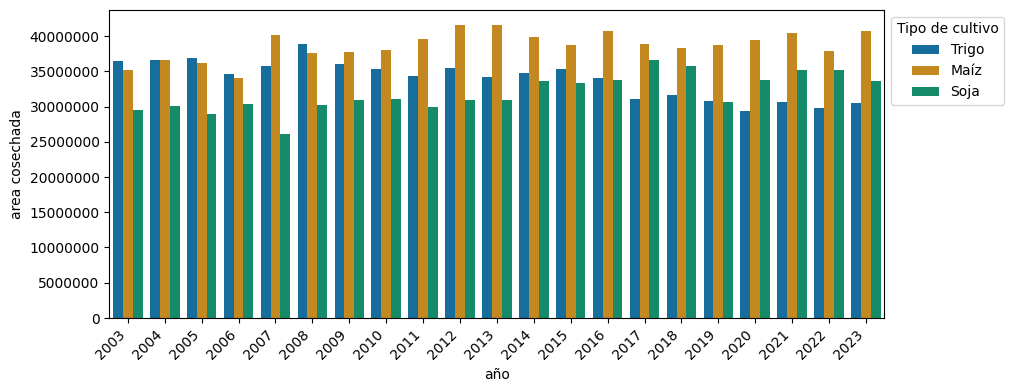

In [298]:
filtro_agri_2 = df_produccion_agri.groupby(["cultivo","año"], as_index=False)["area cosechada"].sum().sort_values(by="area cosechada",
                                                                                                                  ascending=False)

plt.figure(figsize=(10,4))
sns.barplot(data=filtro_agri_2,
            x="año",
            y="area cosechada",
            hue="cultivo",
            palette="colorblind").ticklabel_format(style="plain", axis="y")
plt.legend(
    title="Tipo de cultivo",
    bbox_to_anchor=(1, 1),
    loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Uso de pesticidas** </span>

In [299]:
df_uso_pesticidas = pd.read_csv(r"C:\Users\Usuario\Downloads\Faostat_pesticides_2000_2023.csv")
df_uso_pesticidas.columns = df_uso_pesticidas.columns.str.strip().str.lower().str.replace(" ", "_")
df_uso_pesticidas = df_uso_pesticidas[["area","year","item","value"]]
df_uso_pesticidas = df_uso_pesticidas.rename(columns={"area":"pais",
                                                      "item":"pesticidas",
                                                      "year":"año",
                                                      "value":"cantidad"})

df_uso_pesticidas = df_uso_pesticidas.loc[
    df_uso_pesticidas["pesticidas"] != "Pesticides (total)"
]

nombres = {
    "Herbicides": "Herbicidas",
    "Insecticides": "Insecticidas",
    "Fungicides and Bactericides": "Fungicidas y Bactericidas"
}

df_uso_pesticidas["pesticidas"] = df_uso_pesticidas["pesticidas"].replace(nombres)

df_uso_pesticidas = df_uso_pesticidas[df_uso_pesticidas["año"] != 2000]
df_uso_pesticidas = df_uso_pesticidas[df_uso_pesticidas["año"] != 2001]
df_uso_pesticidas = df_uso_pesticidas[df_uso_pesticidas["año"] != 2002]

df_uso_pesticidas


,pais,año,pesticidas,cantidad
3,France,2003,Insecticidas,2224
4,France,2004,Insecticidas,2460
5,France,2005,Insecticidas,2506
6,France,2006,Insecticidas,2140
7,France,2007,Insecticidas,2101
...,...,...,...,...
859,United States of America,2019,Fungicidas y Bactericidas,15170
860,United States of America,2020,Fungicidas y Bactericidas,14809
861,United States of America,2021,Fungicidas y Bactericidas,14579
862,United States of America,2022,Fungicidas y Bactericidas,14338


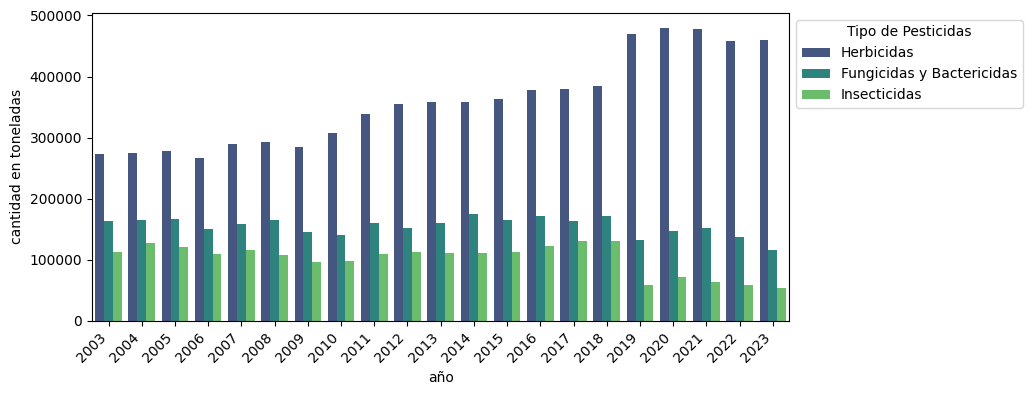

In [300]:
plt.figure(figsize=(9,4))
filtro = df_uso_pesticidas.groupby(["pesticidas","año"], as_index=False)["cantidad"].sum().sort_values(by="cantidad",ascending=False)
filtro = filtro.rename(columns={"cantidad":"cantidad en toneladas"})
sns.barplot(data=filtro,
            x="año",
            y="cantidad en toneladas",
            hue="pesticidas",
            palette="viridis")
plt.legend(
    title="Tipo de Pesticidas",
    bbox_to_anchor=(1, 1),
    loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Temperaturas** </span>

In [ ]:
import os, requests
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
from tqdm import tqdm
START = "2003-01-01"
END = "2023-12-31"
os.makedirs("data/europa", exist_ok=True)
os.makedirs("data/usa", exist_ok=True)

def descargar(url, path):
    if os.path.exists(path):
        return path
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(path, "wb") as f:
        for chunk in tqdm(r.iter_content(1024 * 1024), desc=path):
            if chunk:
                f.write(chunk)
    return path

def get_lat_lon(ds):
    lat = next(x for x in ["latitude", "lat", "y"] if x in ds.coords)
    lon = next(x for x in ["longitude", "lon", "x"] if x in ds.coords)
    return lat, lon

def buscar_var(ds, opciones):
    for v in opciones:
        if v in ds.data_vars:
            return v
    raise ValueError(f"No encuentro variable. Hay: {list(ds.data_vars)}")
# ENLACES EUROPA E-OBS
europe_urls = [
    "https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.25deg_reg_ensemble/tg_ens_mean_0.25deg_reg_1995-2010_v33.0e.nc",
    "https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.25deg_reg_ensemble/tg_ens_mean_0.25deg_reg_2011-2025_v33.0e.nc"
]
europe_files = [
    descargar(url, "data/europa/" + url.split("/")[-1])
    for url in europe_urls
]
# ENLACE USA MENSUAL
usa_url = "https://www.ncei.noaa.gov/pub/data/nidis/indices/nclimgrid-monthly/base-files/nclimgrid-tavg.nc"
usa_file = descargar(usa_url, "data/usa/nclimgrid-tavg.nc")
# PAÍSES EUROPA
countries = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
europe_countries = countries[countries["CONTINENT"] == "Europe"].copy()
europe_countries = europe_countries.reset_index(drop=True)
europe_countries["_rid"] = europe_countries.index
# EUROPA: DIARIO -> MENSUAL -> MEDIA POR PAÍS
ds_eu = xr.open_mfdataset(europe_files, combine="by_coords", chunks="auto")
eu = ds_eu["tg"].sel(time=slice(START, END))
# convertir a mensual primero: esto acelera mucho
eu_monthly = eu.resample(time="MS").mean()
lat_name, lon_name = get_lat_lon(ds_eu)
mask_eu = regionmask.mask_geopandas(
    europe_countries,
    lon_or_obj=ds_eu[lon_name],
    lat=ds_eu[lat_name],
    numbers="_rid"
)
weights_eu = np.cos(np.deg2rad(ds_eu[lat_name]))
spatial_dims_eu = [d for d in eu_monthly.dims if d != "time"]
resultados = []
for _, row in europe_countries.iterrows():
    temp_country = eu_monthly.where(mask_eu == row["_rid"])

    serie = (
        temp_country
        .weighted(weights_eu)
        .mean(dim=spatial_dims_eu, skipna=True)
        .to_dataframe(name="temperatura_media")
        .reset_index()
    )

    serie["country"] = row["ADMIN"]
    serie["iso3"] = row["ISO_A3"]
    serie["source"] = "E-OBS"
    resultados.append(serie)

df_europe = pd.concat(resultados, ignore_index=True)
df_europe = df_europe.rename(columns={"time": "date"})
# USA: YA ES MENSUAL
ds_us = xr.open_dataset(usa_file, chunks="auto")
var_us = buscar_var(ds_us, ["tavg", "tave", "TAVG", "TAVE"])
us = ds_us[var_us].sel(time=slice(START, END))
lat_us, lon_us = get_lat_lon(ds_us)
weights_us = np.cos(np.deg2rad(ds_us[lat_us]))
spatial_dims_us = [d for d in us.dims if d != "time"]
df_usa = (
    us.weighted(weights_us)
      .mean(dim=spatial_dims_us, skipna=True)
      .to_dataframe(name="temperatura_media")
      .reset_index()
      .rename(columns={"time": "date"}))
df_usa["country"] = "United States of America"
df_usa["iso3"] = "USA"
df_usa["source"] = "NOAA nClimGrid Monthly"
df = pd.concat([df_europe, df_usa], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df[["date", "country", "iso3", "source", "temperatura_media"]]
df = df.sort_values(["country", "date"]).reset_index(drop=True)
df_spain = df[df["country"] == "Spain"].copy()
df.to_csv("temperatura_mensual_por_pais_2003_2023.csv", index=False)
df_spain.to_csv("temperatura_mensual_espana_2003_2023.csv", index=False)
print(df.head())
print(df_spain.head())
print(df.shape)

In [ ]:
df["country"].unique()

In [ ]:
paises_map = {
    "Germany": "Alemania",
    "Spain": "España",
    "United States of America": "Estados Unidos de América",
    "France": "Francia",
    "Greece": "Grecia",
    "Italy": "Italia",
    "Netherlands": "Países Bajos",
    "Poland": "Polonia",
    "Portugal": "Portugal",
    "Romania": "Rumanía",
    "Switzerland": "Suiza"
}

df_temperaturas = df[df["country"].isin(paises_map.keys())].copy()

df_temperaturas["country"] = df_temperaturas["country"].map(paises_map)

df_temperaturas = df_temperaturas.sort_values(["country", "date"]).reset_index(drop=True)

df_temperaturas.to_csv("df_temperaturas.csv", index=False)
df_temperaturas["año"] = df_temperaturas["date"].dt.year
df_temperaturas["temperatura_media"] = df_temperaturas["temperatura_media"].round(2)
df_temperaturas = df_temperaturas.rename(columns={"date":"fecha",
                                                  "country":"pais"})
df_temperaturas.to_csv("df_temperaturas.csv")

In [51]:
df_abejas.to_csv("df_abejas.csv")
df_produccion_agri.to_csv("df_produccion_agri.csv")
df_uso_pesticidas.to_csv("df_uso_pesticidas.csv")

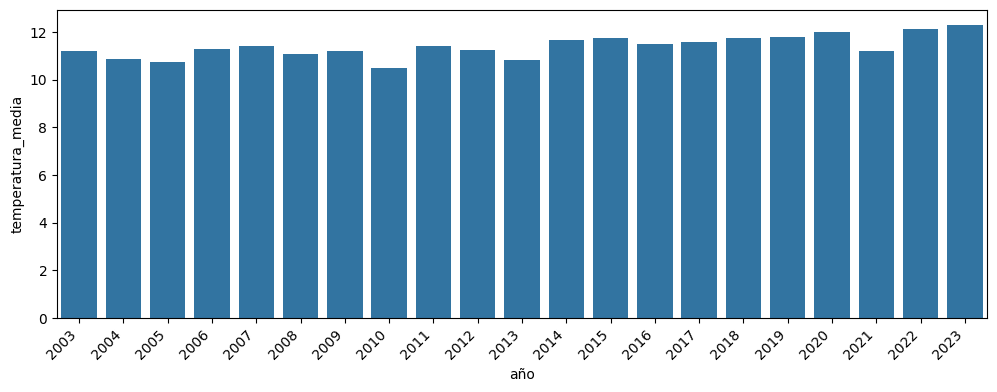

In [323]:
filtro_temp = df_temperaturas.groupby(["año","pais"], as_index=False)["temperatura_media"].mean().round(2)

plt.figure(figsize=(12,4))
sns.barplot(data=filtro_temp,
            x="año",
            y="temperatura_media",
            errorbar=None)

plt.xticks(rotation=45, ha="right")
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Hacemos cruce de datos para ver correlaciones** </span>

In [183]:
df_pesticidas = df_uso_pesticidas.pivot_table(
    index=["pais", "año"],
    columns="pesticidas",
    values="cantidad",
    aggfunc="sum"
).reset_index()

df_pesticidas.columns.name = None

mapa_paises = {
    "France": "Francia",
    "Germany": "Alemania",
    "Greece": "Grecia",
    "Ireland": "Irlanda",
    "Italy": "Italia",
    "Netherlands (Kingdom of the)": "Países Bajos",
    "Poland": "Polonia",
    "Portugal": "Portugal",
    "Romania": "Rumanía",
    "Spain": "España",
    "Switzerland": "Suiza",
    "United States of America": "Estados Unidos"
}
df_pesticidas["pais"] = df_pesticidas["pais"].replace(mapa_paises)

df_corr = df_abejas.merge(
    df_pesticidas,
    on=["pais", "año"],
    how="inner"
)
df_corr[[
    "num_colmenas",
    "Herbicidas",
    "Insecticidas",
    "Fungicidas y Bactericidas"
]].corr()

df_corr = df_corr.sort_values(["pais", "año"])

df_corr["variacion_colmenas"] = (
    df_corr.groupby("pais")["num_colmenas"]
    .pct_change() * 100
)
df_corr[[
    "variacion_colmenas",
    "Herbicidas",
    "Insecticidas",
    "Fungicidas y Bactericidas"
]].corr()
cols_corr = [
    "variacion_colmenas",
    "Herbicidas",
    "Insecticidas",
    "Fungicidas y Bactericidas"
]

corr_total = df_corr[cols_corr].corr()

# Nombres bonitos para mostrar en el heatmap
nombres_2 = {
    "variacion_colmenas": "Variación de colmenas",
    "Herbicidas": "Herbicidas",
    "Insecticidas": "Insecticidas",
    "Fungicidas y Bactericidas": "Fungicidas y bactericidas"
}

corr_total = corr_total.rename(
    index=nombres_2,
    columns=nombres_2
)

In [ ]:
df_corr

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas y uso de pesticidas** </span>

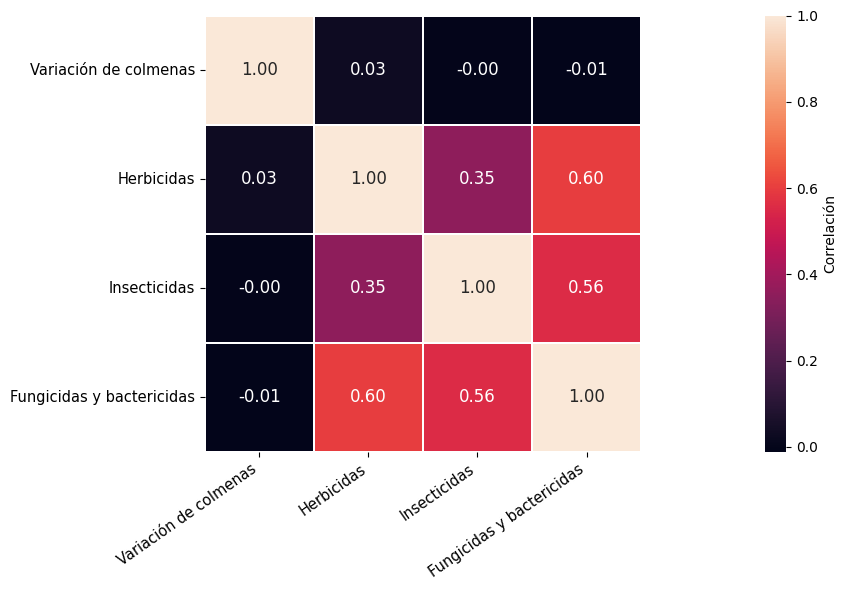

In [208]:
plt.figure(figsize=(25,6))

sns.heatmap(
    corr_total,
    annot=True,
    cmap="rocket",
    center=0.5,
    fmt=".2f",
    linewidths=0.05,
    square=True,
    annot_kws={"size": 12},   # tamaño de los números
    cbar_kws={"label": "Correlación"}
)
plt.xticks(rotation=35, ha="right", fontsize=10.5)
plt.yticks(rotation=0, fontsize=10.5)

plt.tight_layout()
plt.show()

In [ ]:
# Filtrar solo España
df_corr_espana = df_corr.loc[
    df_corr["pais"] == "España"
].copy()
# Columnas para la correlación
cols_corr = [
    "variacion_colmenas",
    "Herbicidas",
    "Insecticidas",
    "Fungicidas y Bactericidas"
]
# Calcular matriz de correlación
corr_espana = df_corr_espana[cols_corr].dropna().corr()
nombres_2 = {
    "variacion_colmenas": "Variación de colmenas",
    "Herbicidas": "Herbicidas",
    "Insecticidas": "Insecticidas",
    "Fungicidas y Bactericidas": "Fungicidas y bactericidas"
}
corr_espana = corr_espana.rename(
    index=nombres_2,
    columns=nombres_2
)
# Heatmap España
plt.figure(figsize=(8, 5.5))

sns.heatmap(
    corr_espana,
    annot=True,
    cmap="rocket",
    center=0.9,
    fmt=".2f",
    linewidths=0.1,
    square=True,
    annot_kws={"size": 12},   # tamaño de los números
    cbar_kws={"label": "Correlación"}
)
plt.xticks(rotation=35, ha="right", fontsize=10.5)
plt.yticks(rotation=0, fontsize=10.5)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Preparar producción agrícola
df_agri = df_produccion_agri

# Asegurar nombres limpios
df_agri = df_agri.rename(columns={
    "país": "pais",
    "area cosechada": "area_cosechada",
    "rendimiento kg/h": "rendimiento",
    "cosecha ":"cosecha"
})
# Normalizar países
mapa_paises = {
    "France": "Francia",
    "Germany": "Alemania",
    "Greece": "Grecia",
    "Ireland": "Irlanda",
    "Italy": "Italia",
    "Netherlands (Kingdom of the)": "Países Bajos",
    "Poland": "Polonia",
    "Portugal": "Portugal",
    "Romania": "Rumanía",
    "Spain": "España",
    "Switzerland": "Suiza",
    "United States of America": "Estados Unidos"}

df_agri["pais"] = df_agri["pais"].replace(mapa_paises)
# Quedarse solo con columnas necesarias

df_agri_total = (
    df_agri.groupby(["pais", "año"], as_index=False)
    .agg(
        area_cosechada_total=("area_cosechada", "sum"),
        cosecha_total=("cosecha", "sum"),
        rendimiento_medio=("rendimiento", "mean")
    )
)
# Cruce con abejas
df_corr_agri = df_abejas.merge(
    df_agri_total,
    on=["pais", "año"],
    how="inner"
)
# Variación anual de colmenas
df_corr_agri = df_corr_agri.sort_values(["pais", "año"])

df_corr_agri["variacion_colmenas"] = (
    df_corr_agri.groupby("pais")["num_colmenas"]
    .pct_change() * 100
)
# Dataset limpio para correlación
df_corr_agri = df_corr_agri.dropna(subset=[
    "variacion_colmenas",
    "area_cosechada_total",
    "cosecha_total",
    "rendimiento_medio"
])
df_corr_agri

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas y extension agricola** </span>

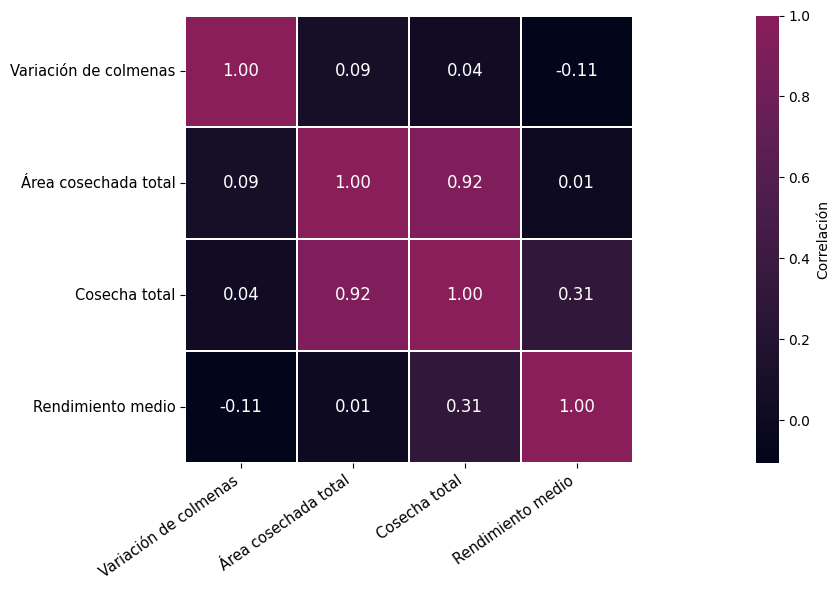

In [236]:
cols_agri = [
    "variacion_colmenas",
    "area_cosechada_total",
    "cosecha_total",
    "rendimiento_medio"
]

corr_agri_total = df_corr_agri[cols_agri].corr()

nombres_agri = {
    "variacion_colmenas": "Variación de colmenas",
    "area_cosechada_total": "Área cosechada total",
    "cosecha_total": "Cosecha total",
    "rendimiento_medio": "Rendimiento medio"
}

corr_agri_total = corr_agri_total.rename(
    index=nombres_agri,
    columns=nombres_agri
)

plt.figure(figsize=(25,6))

sns.heatmap(
    corr_agri_total,
    annot=True,
    cmap="rocket",
    center=1.5,
    fmt=".2f",
    linewidths=0.05,
    square=True,
    annot_kws={"size": 12},
    cbar_kws={"label": "Correlación"}
)
plt.xticks(rotation=35, ha="right", fontsize=10.5)
plt.yticks(rotation=0, fontsize=10.5)

plt.tight_layout()
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas Y extension agricola a nivel nacinal (españa)** </span>

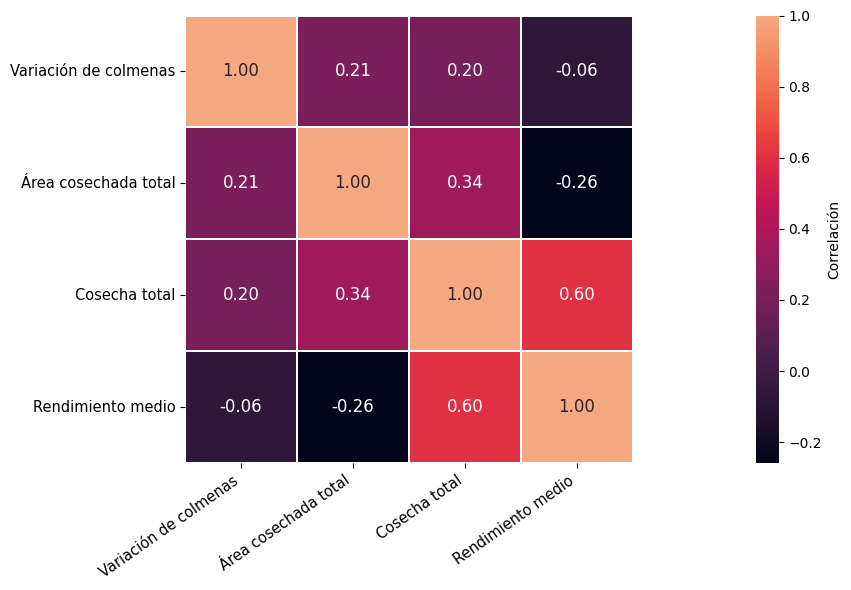

In [242]:
df_corr_agri_espana = df_corr_agri.loc[
    df_corr_agri["pais"] == "España"
].copy()

cols_agri = [
    "variacion_colmenas",
    "area_cosechada_total",
    "cosecha_total",
    "rendimiento_medio"
]

corr_agri_espana = df_corr_agri_espana[cols_agri].corr()

nombres_agri = {
    "variacion_colmenas": "Variación de colmenas",
    "area_cosechada_total": "Área cosechada total",
    "cosecha_total": "Cosecha total",
    "rendimiento_medio": "Rendimiento medio"
}

corr_agri_espana = corr_agri_espana.rename(
    index=nombres_agri,
    columns=nombres_agri
)

plt.figure(figsize=(25,6))

sns.heatmap(
    corr_agri_espana,
    annot=True,
    cmap="rocket",
    center=0.5,
    fmt=".2f",
    linewidths=0.05,
    square=True,
    annot_kws={"size": 12},
    cbar_kws={"label": "Correlación"}
)

plt.xticks(rotation=35, ha="right", fontsize=10.5)
plt.yticks(rotation=0, fontsize=10.5)

plt.tight_layout()
plt.show()

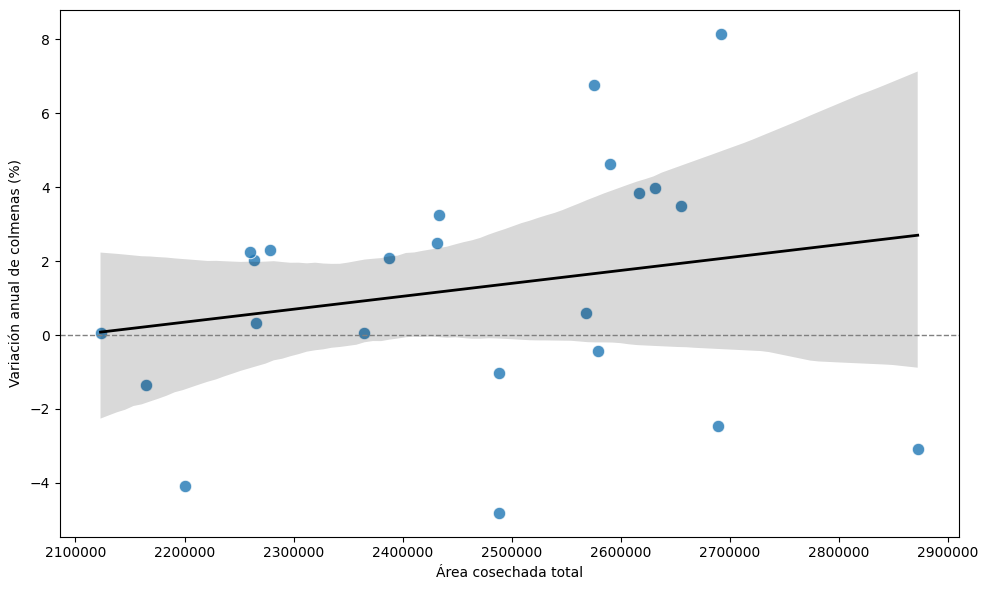

In [244]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_corr_agri_espana,
    x="area_cosechada_total",
    y="variacion_colmenas",
    s=80,
    alpha=0.8
)
sns.regplot(
    data=df_corr_agri_espana,
    x="area_cosechada_total",
    y="variacion_colmenas",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
).ticklabel_format(style="plain", axis="x")
plt.xlabel("Área cosechada total")
plt.ylabel("Variación anual de colmenas (%)")

plt.axhline(0, color="gray", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas Y temperaturas** </span>

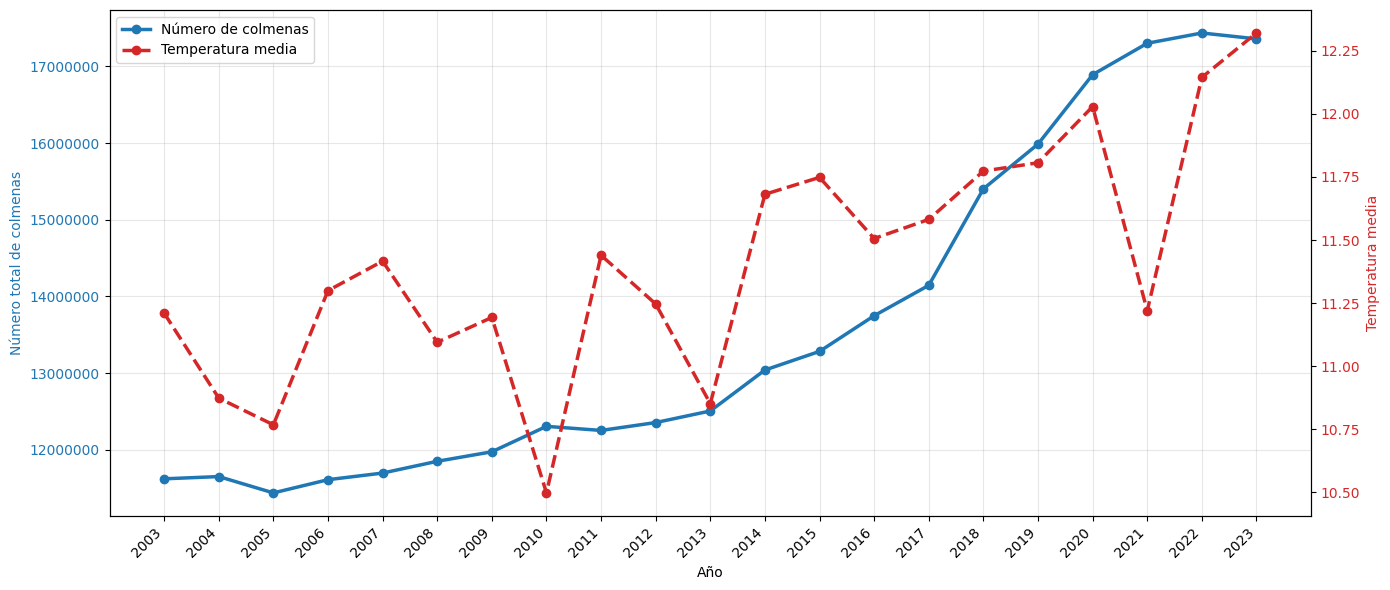

In [251]:
# Temperatura media por año
temp_global = (
    df_temperaturas
    .groupby("año", as_index=False)["temperatura_media"]
    .mean()
)

# Número total de colmenas por año
abejas_global = (
    df_abejas
    .groupby("año", as_index=False)["num_colmenas"]
    .sum()
)

# Unir datos
df_temp_abejas = abejas_global.merge(
    temp_global,
    on="año",
    how="inner"
).sort_values("año")

# Gráfico con doble eje y colores diferenciados
fig, ax1 = plt.subplots(figsize=(14,6))

color_colmenas = "#1f77b4"
color_temp = "#d62728"

ax1.plot(
    df_temp_abejas["año"],
    df_temp_abejas["num_colmenas"],
    marker="o",
    linewidth=2.5,
    color=color_colmenas,
    label="Número de colmenas"
)

ax1.set_xlabel("Año")
ax1.set_ylabel("Número total de colmenas", color=color_colmenas)
ax1.tick_params(axis="y", labelcolor=color_colmenas)
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()

ax2.plot(
    df_temp_abejas["año"],
    df_temp_abejas["temperatura_media"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    color=color_temp,
    label="Temperatura media"
)

ax2.set_ylabel("Temperatura media", color=color_temp)
ax2.tick_params(axis="y", labelcolor=color_temp)

ax1.set_xticks(df_temp_abejas["año"])
ax1.set_xticklabels(df_temp_abejas["año"], rotation=45, ha="right")

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="upper left"
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas Y temperaturas a nivel nacional (españa)** </span>

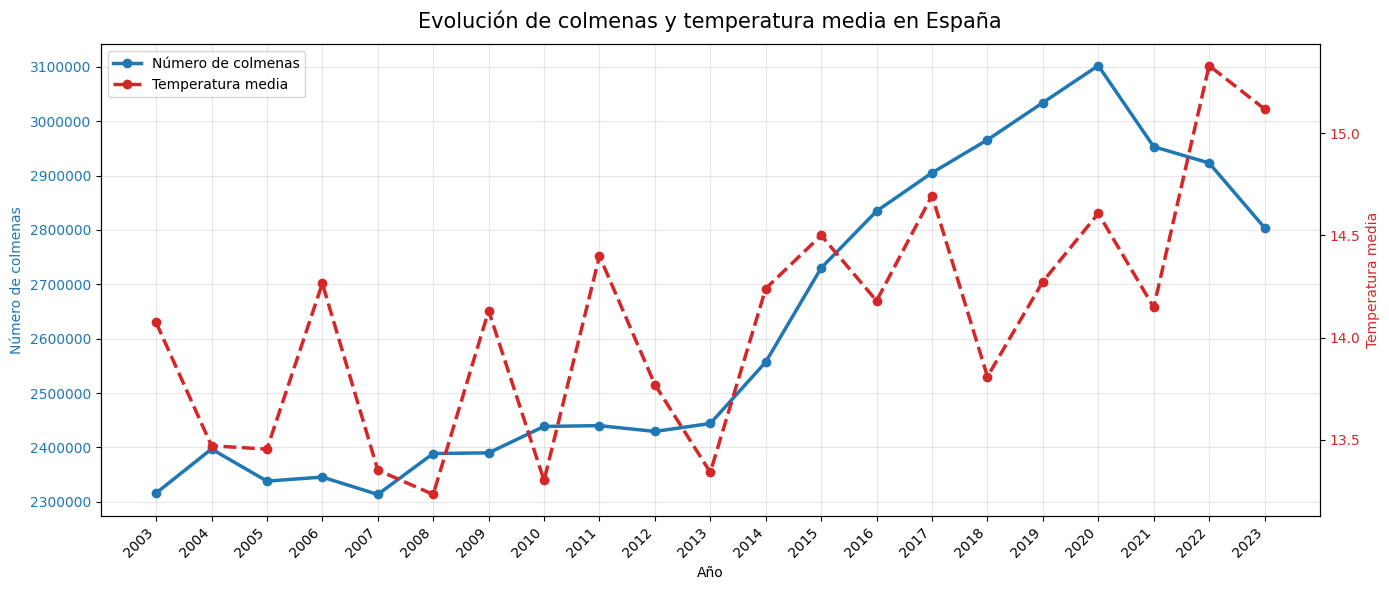

In [262]:
# Temperatura media de España por año
temp_espana = (
    df_temperaturas
    .loc[df_temperaturas["pais"] == "España"]
    .groupby("año", as_index=False)["temperatura_media"]
    .mean()
)
# Número de colmenas de España por año
abejas_espana = (
    df_abejas
    .loc[df_abejas["pais"] == "España"]
    .groupby("año", as_index=False)["num_colmenas"]
    .sum()
)
# Unir datos
df_temp_abejas_espana = abejas_espana.merge(
    temp_espana,
    on="año",
    how="inner"
).sort_values("año")

# Gráfico con doble eje y colores diferenciados
fig, ax1 = plt.subplots(figsize=(14,6))

color_colmenas = "#1f77b4"
color_temp = "#d62728"

ax1.plot(
    df_temp_abejas_espana["año"],
    df_temp_abejas_espana["num_colmenas"],
    marker="o",
    linewidth=2.5,
    color=color_colmenas,
    label="Número de colmenas"
)

ax1.set_xlabel("Año")
ax1.set_ylabel("Número de colmenas", color=color_colmenas)
ax1.tick_params(axis="y", labelcolor=color_colmenas)
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()

ax2.plot(
    df_temp_abejas_espana["año"],
    df_temp_abejas_espana["temperatura_media"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    color=color_temp,
    label="Temperatura media"
)

ax2.set_ylabel("Temperatura media", color=color_temp)
ax2.tick_params(axis="y", labelcolor=color_temp)

ax1.set_xticks(df_temp_abejas_espana["año"])
ax1.set_xticklabels(df_temp_abejas_espana["año"], rotation=45, ha="right")

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="upper left"
)

plt.title(
    "Evolución de colmenas y temperatura media en España",
    fontsize=15,
    pad=12
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas Y temperaturas de paises del sur de europa** </span>

In [254]:
# Base común: colmenas + temperatura por país y año
temp_pais = df_temperaturas.groupby(["pais", "año"], as_index=False)["temperatura_media"].mean()
abejas_pais = df_abejas.groupby(["pais", "año"], as_index=False)["num_colmenas"].sum()

df_temp_colmenas = abejas_pais.merge(
    temp_pais,
    on=["pais", "año"],
    how="inner"
).sort_values(["pais", "año"])

df_temp_colmenas["variacion_colmenas"] = (
    df_temp_colmenas.groupby("pais")["num_colmenas"].pct_change() * 100
)

# Filtro países del sur
paises_sur = ["España", "Italia", "Grecia", "Portugal"]

df_sur = df_temp_colmenas.loc[
    df_temp_colmenas["pais"].isin(paises_sur)
].copy()

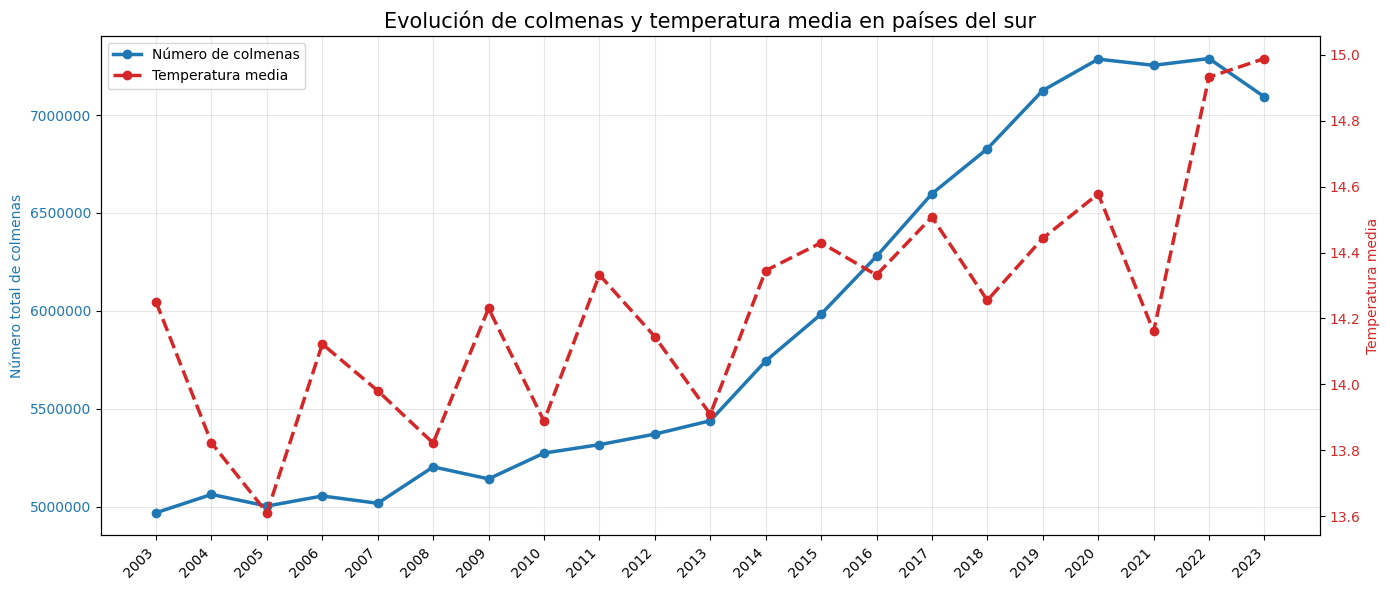

In [263]:
df_sur_anual = df_sur.groupby("año", as_index=False).agg(
    num_colmenas=("num_colmenas", "sum"),
    temperatura_media=("temperatura_media", "mean")
)

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df_sur_anual["año"], df_sur_anual["num_colmenas"],
         marker="o", color="#1f77b4", linewidth=2.5, label="Número de colmenas")

ax1.set_ylabel("Número total de colmenas", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()

ax2.plot(df_sur_anual["año"], df_sur_anual["temperatura_media"],
         marker="o", linestyle="--", color="#d62728", linewidth=2.5, label="Temperatura media")

ax2.set_ylabel("Temperatura media", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax1.set_xticks(df_sur_anual["año"])
ax1.set_xticklabels(df_sur_anual["año"], rotation=45, ha="right")

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left")

plt.title("Evolución de colmenas y temperatura media en países del sur", fontsize=15)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas Y temperaturas de paises del norte de europa** </span>

In [258]:
paises_norte = ["Francia", "Alemania", "Polonia", "Suiza", "Países Bajos", "Irlanda"]

df_norte = df_temp_colmenas.loc[
    df_temp_colmenas["pais"].isin(paises_norte)
].copy()

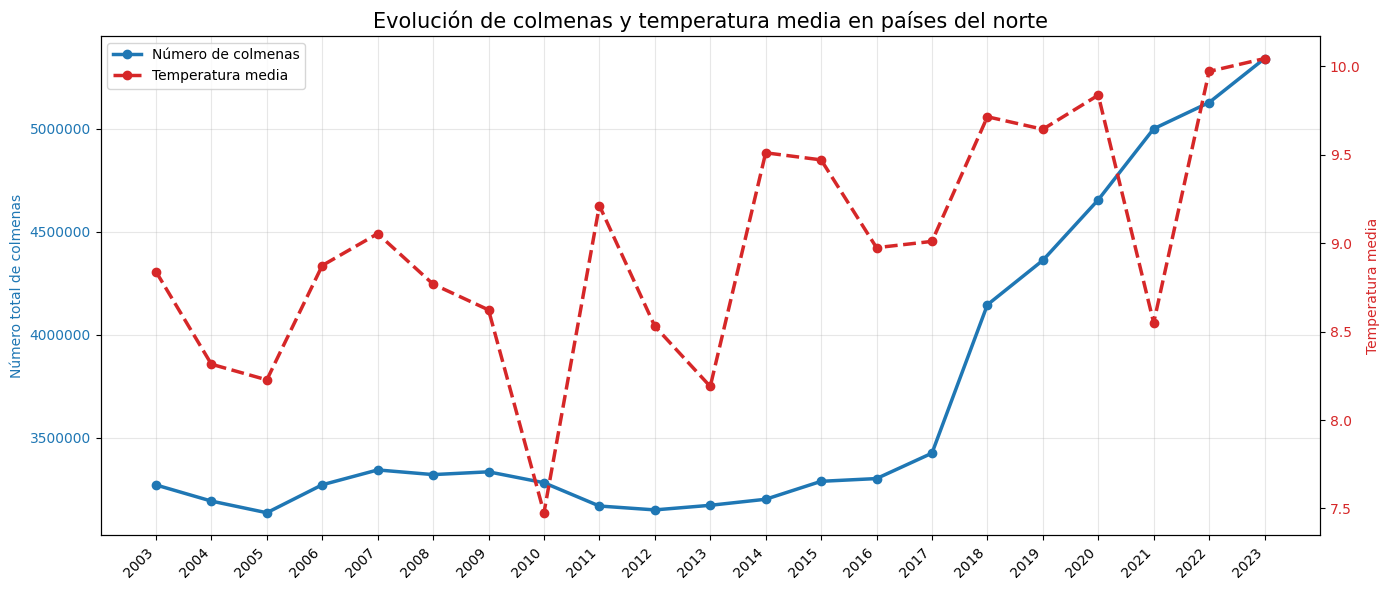

In [264]:
df_norte_anual = df_norte.groupby("año", as_index=False).agg(
    num_colmenas=("num_colmenas", "sum"),
    temperatura_media=("temperatura_media", "mean")
)

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df_norte_anual["año"], df_norte_anual["num_colmenas"],
         marker="o", color="#1f77b4", linewidth=2.5, label="Número de colmenas")

ax1.set_ylabel("Número total de colmenas", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()

ax2.plot(df_norte_anual["año"], df_norte_anual["temperatura_media"],
         marker="o", linestyle="--", color="#d62728", linewidth=2.5, label="Temperatura media")

ax2.set_ylabel("Temperatura media", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax1.set_xticks(df_norte_anual["año"])
ax1.set_xticklabels(df_norte_anual["año"], rotation=45, ha="right")

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left")

plt.title("Evolución de colmenas y temperatura media en países del norte", fontsize=15)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style= "color: rgba(89, 228, 145, 0.88);"> **Num de colmenas perdidas y el remplazo** </span>

In [ ]:
### Datos de remplazo de abjeas 

df_nass = pd.read_csv(r"C:\Users\Usuario\Downloads\NASS_Bee-Colony_2015-2021.csv")

df_nass.columns = (
    df_nass.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Separar año y trimestre
df_nass["año"] = df_nass["year"].str.extract(r"(\d{4})").astype(int)
df_nass["trimestre"] = df_nass["year"].str.extract(r"(Q\d)")

# Limpiar valores especiales
cols_num = [
    "starting_colonies",
    "maximum_colonies",
    "lost_colonies",
    "percent_loss",
    "added_colonies",
    "renovated_colonies",
    "percent_renovated"
]

for col in cols_num:
    df_nass[col] = (
        df_nass[col]
        .replace({"(NA)": np.nan, "(X)": np.nan, "(Z)": 0})
        .astype(float)
    )

# Variable proxy de reposición
df_nass["reposicion_colonias"] = (
    df_nass["added_colonies"] + df_nass["renovated_colonies"]
)

In [272]:
df_nass_anual = (
    df_nass
    .groupby("año", as_index=False)
    .agg(
        colonias_inicio=("starting_colonies", "sum"),
        colonias_maximas=("maximum_colonies", "sum"),
        colonias_perdidas=("lost_colonies", "sum"),
        colonias_anadidas=("added_colonies", "sum"),
        colonias_renovadas=("renovated_colonies", "sum"),
        reposicion_colonias=("reposicion_colonias", "sum")
    )
)

df_nass_anual["porcentaje_perdida"] = (
    df_nass_anual["colonias_perdidas"] / df_nass_anual["colonias_maximas"] * 100
)

df_nass_anual["porcentaje_reposicion"] = (
    df_nass_anual["reposicion_colonias"] / df_nass_anual["colonias_maximas"] * 100
)

df_nass_anual["balance_reposicion"] = (
    df_nass_anual["reposicion_colonias"] - df_nass_anual["colonias_perdidas"]
)

df_nass_anual["reposicion_sobre_perdidas"] = (
    df_nass_anual["reposicion_colonias"] / df_nass_anual["colonias_perdidas"] * 100
)

df_nass_anual

,año,colonias_inicio,colonias_maximas,colonias_perdidas,colonias_anadidas,colonias_renovadas,reposicion_colonias,porcentaje_perdida,porcentaje_reposicion,balance_reposicion,reposicion_sobre_perdidas
0,2015,23363500.0,14781830.0,3444720.0,2997960.0,2850480.0,5848440.0,23.303745,39.565061,2403720.0,169.779837
1,2016,23269300.0,14801120.0,3291120.0,3301560.0,2297480.0,5599040.0,22.235615,37.828489,2307920.0,170.125672
2,2017,22359020.0,14013320.0,3007820.0,3160960.0,3334600.0,6495560.0,21.464007,46.352756,3487740.0,215.955742
3,2018,22257720.0,14249550.0,3230300.0,3341760.0,3209780.0,6551540.0,22.669488,45.977171,3321240.0,202.815218
4,2019,17731080.0,10704380.0,2483820.0,1467040.0,1251660.0,2718700.0,23.203773,25.398015,234880.0,109.456402
5,2020,24317540.0,15197110.0,3225020.0,3334220.0,2581740.0,5915960.0,21.221272,38.928191,2690940.0,183.439483
6,2021,11556620.0,7283450.0,1256980.0,1972440.0,1273300.0,3245740.0,17.258030,44.563222,1988760.0,258.217315


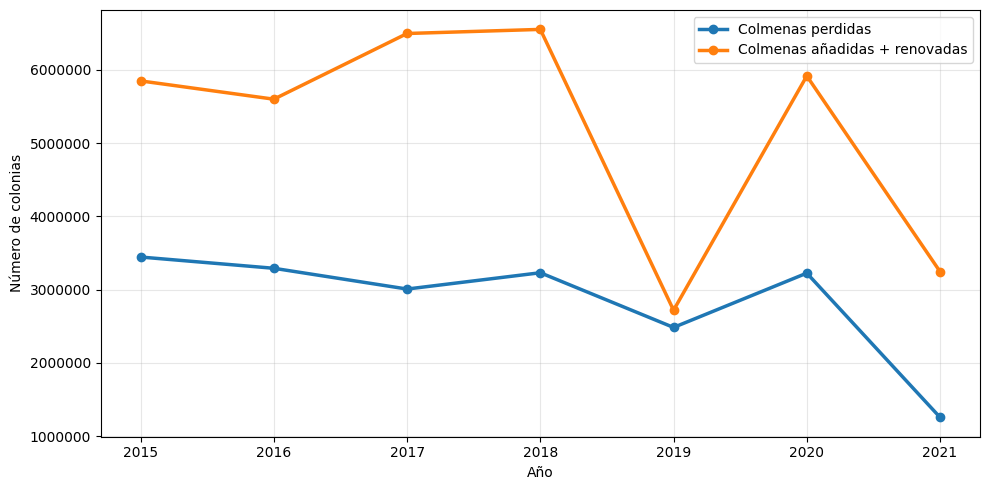

In [307]:
plt.figure(figsize=(10,5))

plt.plot(
    df_nass_anual["año"],
    df_nass_anual["colonias_perdidas"],
    marker="o",
    linewidth=2.5,
    label="Colmenas perdidas"
)

plt.plot(
    df_nass_anual["año"],
    df_nass_anual["reposicion_colonias"],
    marker="o",
    linewidth=2.5,
    label="Colmenas añadidas + renovadas"
)

plt.xlabel("Año")
plt.ylabel("Número de colonias")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

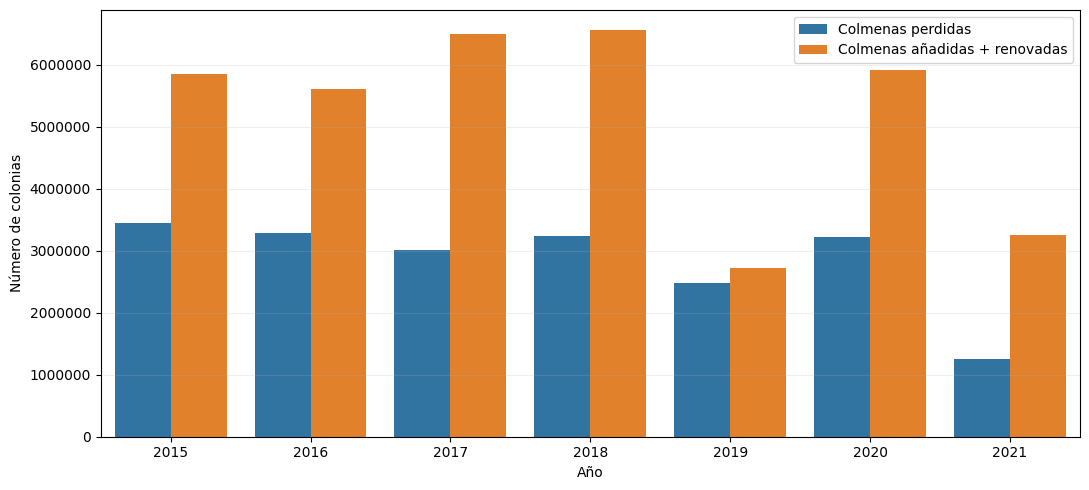

In [304]:
df_plot_barras = df_nass_anual[[
    "año",
    "colonias_perdidas",
    "reposicion_colonias"
]].copy()

df_plot_barras = df_plot_barras.rename(columns={
    "colonias_perdidas": "Colmenas perdidas",
    "reposicion_colonias": "Colmenas añadidas + renovadas"
})

df_plot_barras = df_plot_barras.melt(
    id_vars="año",
    var_name="tipo",
    value_name="colonias"
)

plt.figure(figsize=(11,5))

sns.barplot(
    data=df_plot_barras,
    x="año",
    y="colonias",
    hue="tipo"
)



plt.xlabel("Año")
plt.ylabel("Número de colonias")
plt.ticklabel_format(style="plain", axis="y")

plt.legend(title="")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()